Shapiro-Wilk (Training): ShapiroResult(statistic=np.float64(0.9635690567671803), pvalue=np.float64(0.22141701390670343))
Shapiro-Wilk (Memory): ShapiroResult(statistic=np.float64(0.9667065008906368), pvalue=np.float64(0.2816663131170607))
Levene (Training): LeveneResult(statistic=np.float64(0.4346076458752513), pvalue=np.float64(0.8730505780891101))
Levene (Memory): LeveneResult(statistic=np.float64(0.8274582560296846), pvalue=np.float64(0.5722200263972532))

ANOVA Training Day Errors:
                      sum_sq    df         F    PR(>F)
AD_Status             3.025   1.0  1.216080  0.278356
Treatment            28.275   3.0  3.788945  0.019678
AD_Status:Treatment   9.075   3.0  1.216080  0.319771
Residual             79.600  32.0       NaN       NaN

ANOVA Memory Day Errors:
                       sum_sq    df          F        PR(>F)
AD_Status            189.225   1.0  75.313433  6.449421e-10
Treatment             14.475   3.0   1.920398  1.461176e-01
AD_Status:Treatment    8.675   

C:\Users\ACER\AppData\Local\Temp\ipykernel_26212\973791443.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"Levene (Training): {stats.levene(*[g['Training'] for n, g in df.groupby(['AD_Status', 'Treatment'])])}")
C:\Users\ACER\AppData\Local\Temp\ipykernel_26212\973791443.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"Levene (Memory): {stats.levene(*[g['Memory'] for n, g in df.groupby(['AD_Status', 'Treatment'])])}")



Post-hoc Training (Treatment):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2      1.5  0.172 -0.4223  3.4223  False
     1      3      0.9 0.5931 -1.0223  2.8223  False
     1      4     -0.7 0.7612 -2.6223  1.2223  False
     2      3     -0.6 0.8347 -2.5223  1.3223  False
     2      4     -2.2 0.0196 -4.1223 -0.2777   True
     3      4     -1.6 0.1314 -3.5223  0.3223  False
----------------------------------------------------


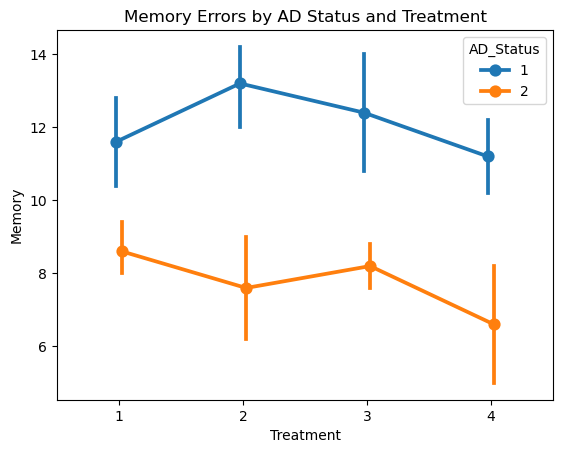

In [4]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

#load dataset
df = pd.read_csv('Alzheimers Mice Data.csv')
df['AD_Status'] = df['AD_Status'].astype('category')
df['Treatment'] = df['Treatment'].astype('category')

#checking
model_t = ols('Training ~ AD_Status * Treatment', data=df).fit()
print(f"Shapiro-Wilk (Training): {stats.shapiro(model_t.resid)}")

model_m = ols('Memory ~ AD_Status * Treatment', data=df).fit()
print(f"Shapiro-Wilk (Memory): {stats.shapiro(model_m.resid)}")

#homogeneity of variance
print(f"Levene (Training): {stats.levene(*[g['Training'] for n, g in df.groupby(['AD_Status', 'Treatment'])])}")
print(f"Levene (Memory): {stats.levene(*[g['Memory'] for n, g in df.groupby(['AD_Status', 'Treatment'])])}")

#2-way anova
anova_t = sm.stats.anova_lm(model_t, typ=2)
anova_m = sm.stats.anova_lm(model_m, typ=2)

print("\nANOVA Training Day Errors:\n", anova_t)
print("\nANOVA Memory Day Errors:\n", anova_m)

#post-hoc tests(tukey hsd)
print("\nPost-hoc Training (Treatment):\n", pairwise_tukeyhsd(df['Training'], df['Treatment']))

#plot
sns.pointplot(data=df, x='Treatment', y='Memory', hue='AD_Status', dodge=True)
plt.title('Memory Errors by AD Status and Treatment')
plt.show()

## APA Format Report
The study was conducted to know the effects of Alzheimer's Disease status (Transgenic vs. Wild Type) and Drug Treatment (Drugs 1, 2, 3, and 4) on the number of errors made during a maze test on two separate occasions: Training Day and Memory Day.

We assume for the 2-Way ANOVA were tested prior to the main analysis.

Normality: The Shapiro-Wilk test on the residuals indicated that the data for both Training Day (W = 0.96, p = .221) and Memory Day (W = 0.97, p = .282) did not significantly deviate from a normal distribution.
Homogeneity of Variance: Levene’s test confirmed that variances were equal across all groups for both Training Day, F(7, 32) = 0.43, p = .873, and Memory Day, F(7, 32) = 0.83, p = .572.

In conclusion, the results shows while genetic modification (AD status) did not hinder the initial training phase, it significantly impaired long-term memory performance. Conversely, while specific drug treatments (Drug 4) improved performance during the training phase compared to others (Drug 2), these effects did not significantly improve memory outcomes on the subsequent test day.
